<a href="https://colab.research.google.com/github/Dheerajpareek13/Introduction/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

 1. LOAD DATA

In [27]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

Clean TotalCharges column

In [40]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
print("Shape after cleaning TotalCharges and dropping NaNs:", df.shape)
print(df.head())

Shape after cleaning TotalCharges and dropping NaNs: (7032, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

In [29]:
print("Shape:", df.shape)
print(df.head())

Shape: (7032, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

2. LOAD INTO SQLITE

In [30]:
conn = sqlite3.connect("churn.db")
df.to_sql("customers", conn, if_exists="replace", index=False)

7032

3. SQL QUERIES

 Q1: Overall churn rate

In [31]:
q1 = pd.read_sql("""
    SELECT Churn,
           COUNT(*) as total,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customers), 2) as percentage
    FROM customers
    GROUP BY Churn
""", conn)
print("\n--- Churn Rate ---")
print(q1)


--- Churn Rate ---
  Churn  total  percentage
0    No   5163       73.42
1   Yes   1869       26.58


Q2: Churn by Contract Type

In [32]:
q2 = pd.read_sql("""
    SELECT Contract,
           SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) as churned,
           COUNT(*) as total,
           ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as churn_rate
    FROM customers
    GROUP BY Contract
    ORDER BY churn_rate DESC
""", conn)
print("\n--- Churn by Contract ---")
print(q2)


--- Churn by Contract ---
         Contract  churned  total  churn_rate
0  Month-to-month     1655   3875       42.71
1        One year      166   1472       11.28
2        Two year       48   1685        2.85


 Q3: Churn by Payment Method

In [33]:
q3 = pd.read_sql("""
    SELECT PaymentMethod,
           ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as churn_rate
    FROM customers
    GROUP BY PaymentMethod
    ORDER BY churn_rate DESC
""", conn)
print("\n--- Churn by Payment Method ---")
print(q3)


--- Churn by Payment Method ---
               PaymentMethod  churn_rate
0           Electronic check       45.29
1               Mailed check       19.20
2  Bank transfer (automatic)       16.73
3    Credit card (automatic)       15.25


 Q4: Avg tenure of churned vs not churned

In [34]:
q4 = pd.read_sql("""
    SELECT Churn,
           ROUND(AVG(tenure),1) as avg_tenure_months,
           ROUND(AVG(MonthlyCharges),2) as avg_monthly_charge
    FROM customers
    GROUP BY Churn
""", conn)
print("\n--- Tenure & Charges ---")
print(q4)

conn.close()


--- Tenure & Charges ---
  Churn  avg_tenure_months  avg_monthly_charge
0    No               37.7               61.31
1   Yes               18.0               74.44


4. VISUALIZATIONS

Text(0.5, 0.98, 'Customer Churn Analysis')

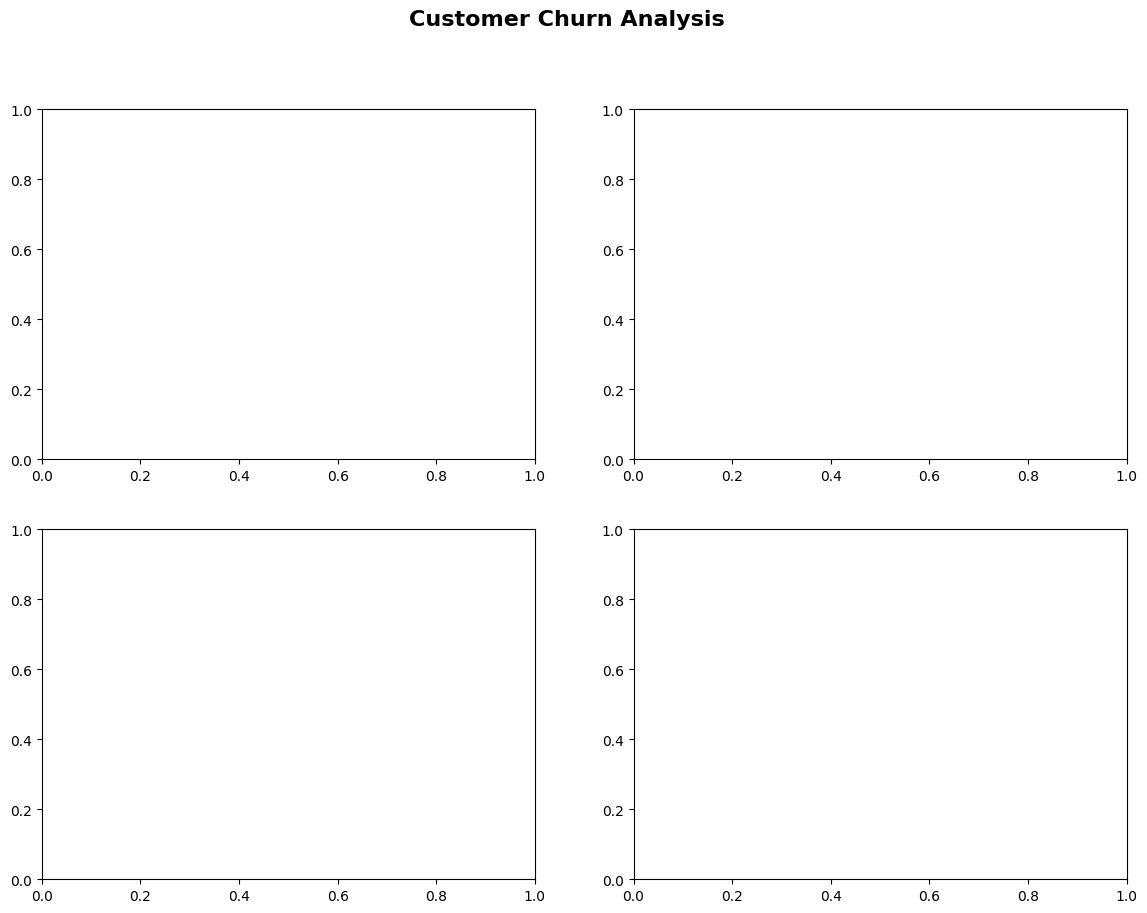

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Customer Churn Analysis", fontsize=16, fontweight="bold")

 Chart 1: Churn Distribution

In [36]:
churn_counts = df["Churn"].value_counts()
axes[0, 0].pie(churn_counts, labels=churn_counts.index,
               autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[0, 0].set_title("Overall Churn Rate")

Text(0.5, 1.0, 'Overall Churn Rate')

 Chart 2: Churn by Contract Type

In [37]:
contract_churn = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100).reset_index()
contract_churn.columns = ["Contract", "Churn Rate (%)"]
axes[0, 1].bar(contract_churn["Contract"], contract_churn["Churn Rate (%)"],
               color=["#e74c3c", "#f39c12", "#2ecc71"])
axes[0, 1].set_title("Churn Rate by Contract Type")
axes[0, 1].set_ylabel("Churn Rate (%)")

Text(596.2626262626262, 0.5, 'Churn Rate (%)')

Chart 3: Tenure Distribution for Churned vs Not

In [38]:
axes[1, 0].hist(df[df["Churn"] == "Yes"]["tenure"], bins=20,
                alpha=0.7, color="#e74c3c", label="Churned")
axes[1, 0].hist(df[df["Churn"] == "No"]["tenure"], bins=20,
                alpha=0.7, color="#2ecc71", label="Retained")
axes[1, 0].set_title("Tenure Distribution")
axes[1, 0].set_xlabel("Months")
axes[1, 0].legend()

 Chart 4: Monthly Charges vs Churn

In [39]:
churn_yes = df[df["Churn"] == "Yes"]["MonthlyCharges"]
churn_no  = df[df["Churn"] == "No"]["MonthlyCharges"]
axes[1, 1].boxplot([churn_no, churn_yes], labels=["Retained", "Churned"])
axes[1, 1].set_title("Monthly Charges vs Churn")
axes[1, 1].set_ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.savefig("churn_analysis.png", dpi=150)
plt.show()
print("\nChart saved as churn_analysis.png")

/tmp/ipykernel_3859/1304590820.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([churn_no, churn_yes], labels=["Retained", "Churned"])


<Figure size 640x480 with 0 Axes>


Chart saved as churn_analysis.png


**Key Findings**
- Month-to-month customers churn at ~42% vs only 3% for 2-year contracts
- Customers using Electronic Check payment churn 2x more than auto-pay users
- Average churned customer tenure = 17 months vs 37 months for retained
- High monthly charges (>$65) strongly correlate with churn

**Business Recommendations**
1. Offer discounts to convert month-to-month users to annual contracts
2. Incentivize auto-pay enrollment to reduce churn
3. Focus retention campaigns on customers in months 10-**20**